In [93]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent

assert (ROOT / 'scripts').exists(), f'Project root not found: {ROOT}'

## Метрики на SVHN test

In [94]:
metrics_path = ROOT / 'runs' / 'eval' / 'svhn_test_test_metrics.json'
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

for key, value in metrics.items():
    print(f'{key:>10}: {value:.4f}')

 precision: 0.8260
    recall: 0.8790
  mean_iou: 0.7843
     map50: 0.8962
  map50_95: 0.5386


## Графики обучения

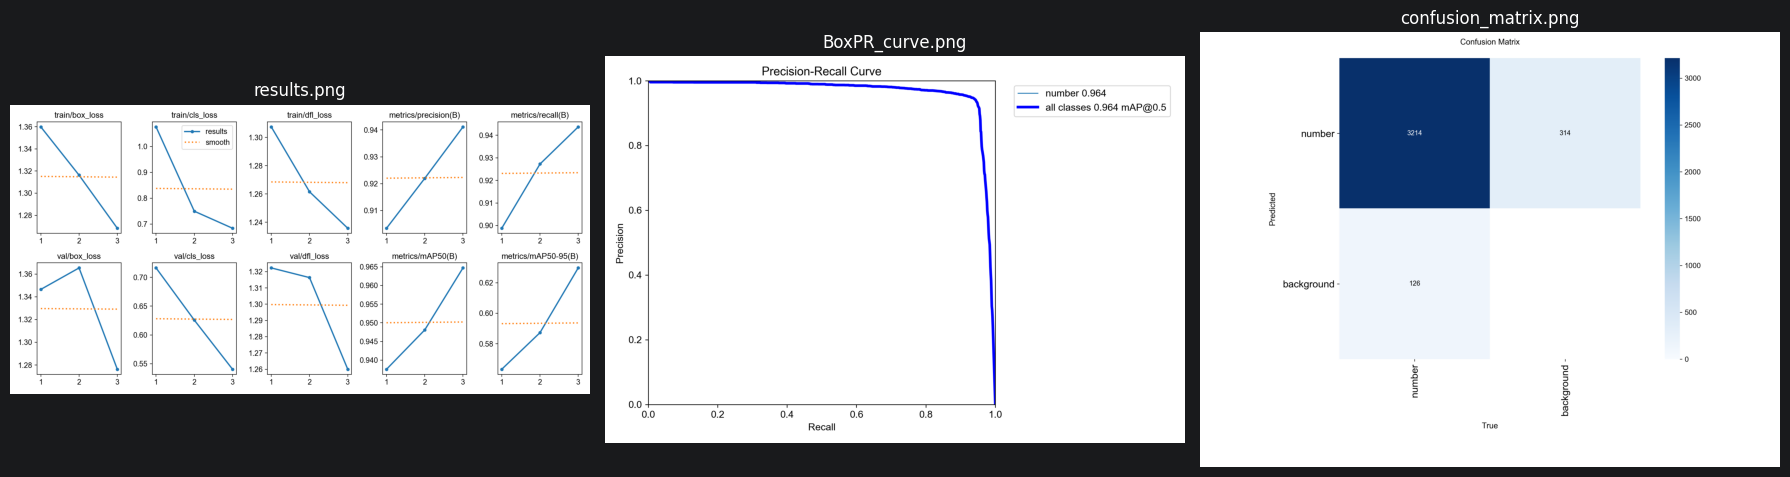

In [95]:
artifacts_dir = ROOT / 'runs' / 'detect' / 'svhn_test'
image_paths = [
    artifacts_dir / 'results.png',
    artifacts_dir / 'BoxPR_curve.png',
    artifacts_dir / 'confusion_matrix.png',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, path in zip(axes, image_paths):
    ax.imshow(Image.open(path))
    ax.set_title(path.name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Предсказания на пользовательских фото

In [96]:
predictions_path = ROOT / 'runs' / 'predict' / 'custom' / 'predictions.json'
predictions = json.loads(predictions_path.read_text(encoding='utf-8'))
predictions

[{'image': 'img.png',
  'detections': [{'bbox_xyxy': [429.83, 392.47, 501.43, 444.07],
    'confidence': 0.491},
   {'bbox_xyxy': [555.04, 389.92, 603.93, 439.27], 'confidence': 0.4005}]},
 {'image': 'img_1.png',
  'detections': [{'bbox_xyxy': [248.66, 315.51, 462.77, 377.78],
    'confidence': 0.3533}]},
 {'image': 'img_2.png',
  'detections': [{'bbox_xyxy': [312.45, 99.76, 356.47, 156.78],
    'confidence': 0.4876},
   {'bbox_xyxy': [132.04, 256.2, 234.65, 330.11], 'confidence': 0.4401},
   {'bbox_xyxy': [289.07, 377.87, 424.18, 459.88], 'confidence': 0.305}]},
 {'image': 'img_3.png', 'detections': []},
 {'image': 'img_4.png',
  'detections': [{'bbox_xyxy': [238.98, 231.74, 269.71, 261.11],
    'confidence': 0.426},
   {'bbox_xyxy': [443.64, 350.25, 541.49, 412.81], 'confidence': 0.2846}]},
 {'image': 'photo_1_2026-04-08_17-14-33.png',
  'detections': [{'bbox_xyxy': [85.55, 108.61, 142.1, 176.18],
    'confidence': 0.7607},
   {'bbox_xyxy': [223.33, 38.81, 249.8, 78.05], 'confidence'

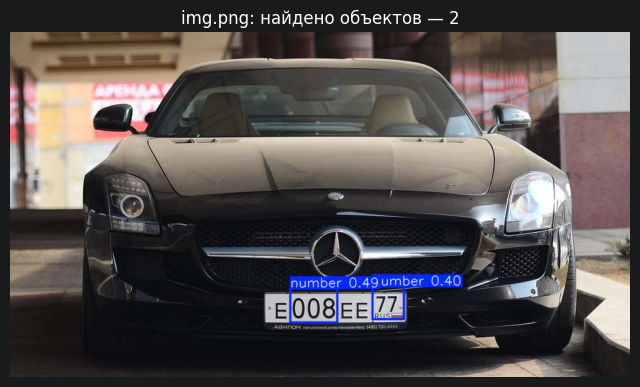

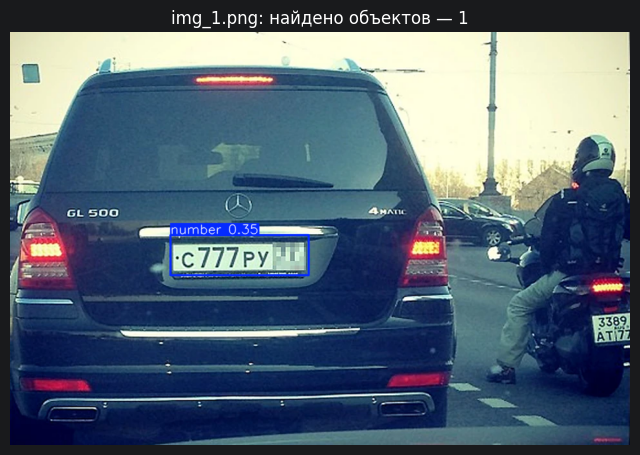

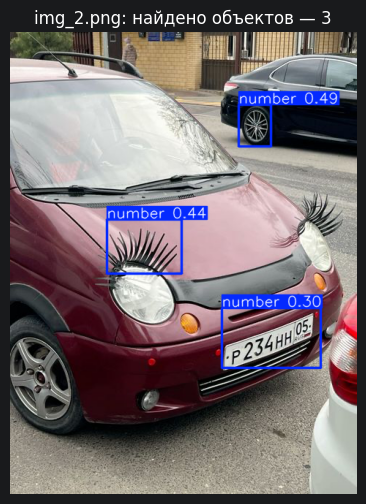

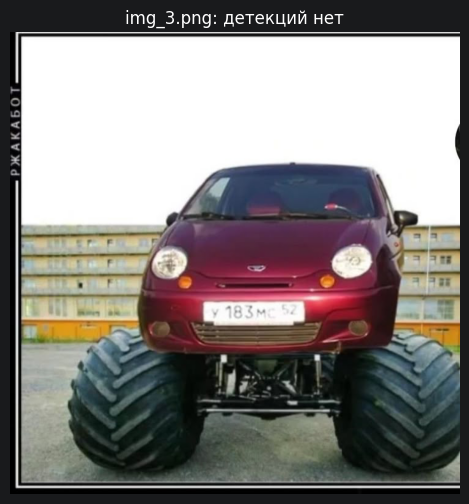

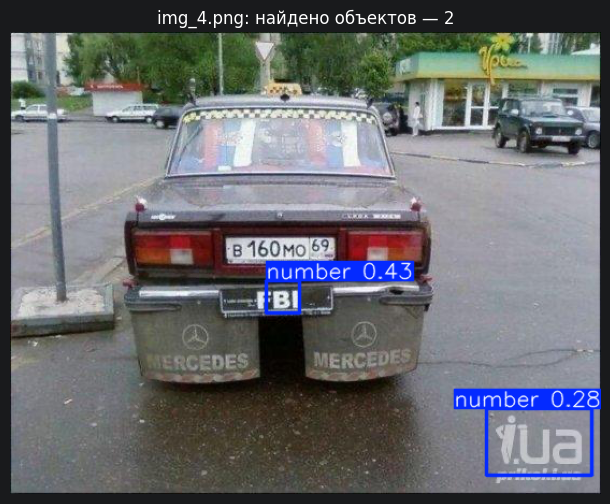

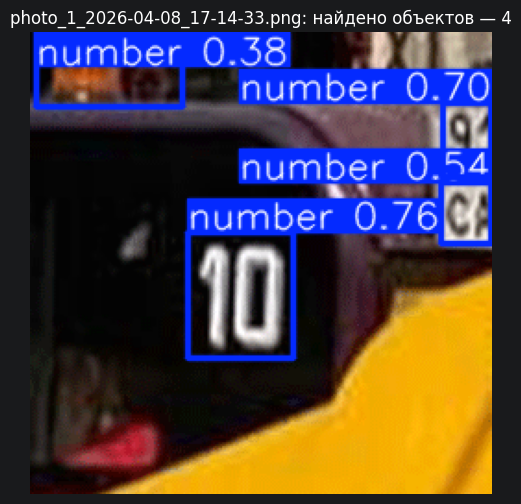

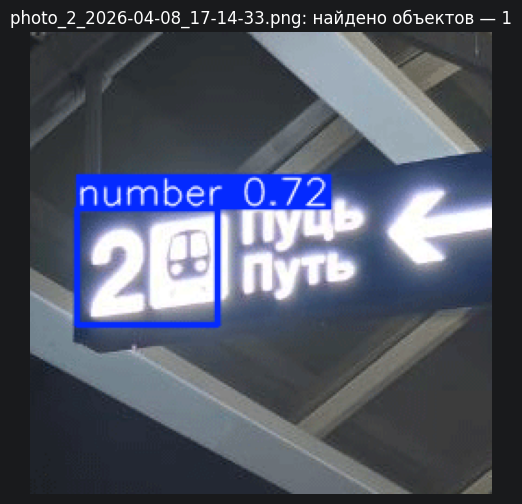

In [97]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from PIL import Image

predictions_path = ROOT / "runs" / "predict" / "custom" / "predictions.json"
predictions = json.loads(predictions_path.read_text(encoding="utf-8"))

images_dir = ROOT / "runs" / "predict" / "custom"

for item in predictions:
    image_path = images_dir / item["image"]

    if not image_path.exists():
        print(f"Не найден файл: {image_path}")
        continue

    image = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")

    detections = item.get("detections", [])

    if detections:
        plt.title(
            f'{item["image"]}: найдено объектов — {len(detections)}'
        )
    else:
        plt.title(
            f'{item["image"]}: детекций нет'
        )

    plt.show()